Código para ler dataset:

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('tmdb_5000_movies.csv')

# Investigando valores ausentes e duplicados
print("Valores Ausentes:\n", df.isnull().sum())
print("Registros Duplicados:", df.duplicated().sum())

# Inconsistências (Muitos filmes no TMDB têm orçamento e receita zerados, o que é um erro de coleta)
print("Filmes com budget zerado:", (df['budget'] == 0).sum())
print("Filmes com revenue zerada:", (df['revenue'] == 0).sum())

Valores Ausentes:
 budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64
Registros Duplicados: 0
Filmes com budget zerado: 1037
Filmes com revenue zerada: 1427


               count          mean           std        min           25%  \
budget        3766.0  3.704284e+07  4.264651e+07   1.000000  8.000000e+06   
popularity    4802.0  2.149678e+01  3.181845e+01   0.000372  4.671734e+00   
revenue       3376.0  1.170314e+08  1.834831e+08   5.000000  1.535290e+07   
runtime       4766.0  1.076607e+02  2.074942e+01  14.000000  9.400000e+01   
vote_average  4740.0  6.173143e+00  9.726836e-01   0.500000  5.600000e+00   

                       50%           75%           max     variancia  \
budget        2.300000e+07  5.000000e+07  3.800000e+08  1.818725e+15   
popularity    1.292493e+01  2.833202e+01  8.755813e+02  1.012414e+03   
revenue       5.175184e+07  1.401651e+08  2.787965e+09  3.366604e+16   
runtime       1.040000e+02  1.180000e+02  3.380000e+02  4.305386e+02   
vote_average  6.200000e+00  6.800000e+00  1.000000e+01  9.461133e-01   

              coef_variação  assimetria  
budget             1.151276    2.224305  
popularity         1

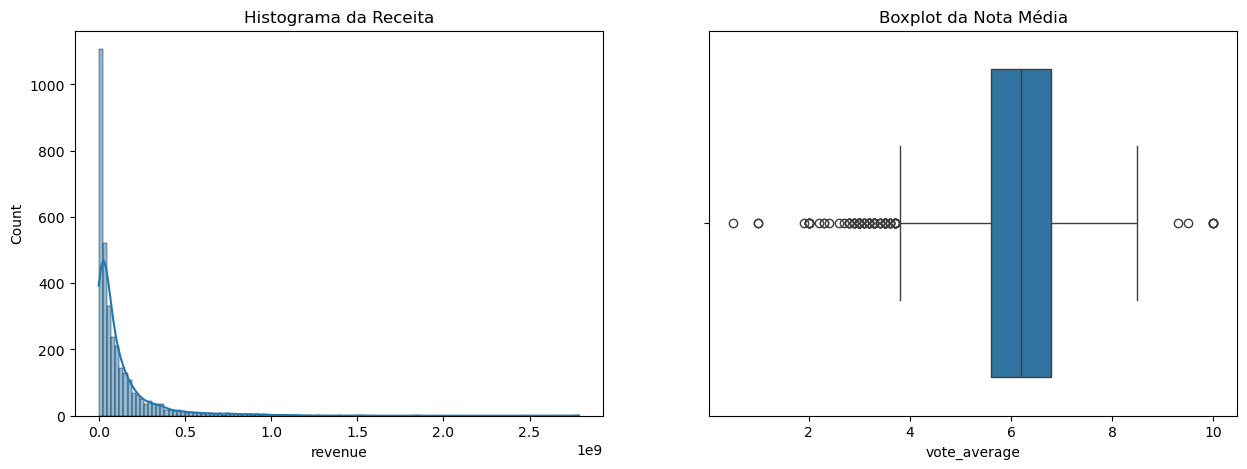

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertendo inconsistências para NaN antes de calcular
num_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average']
df[num_cols] = df[num_cols].replace(0, np.nan)

# Cálculo das métricas exigidas
stats = df[num_cols].describe().T # Média, Mediana (50%), Desvio-padrão e Quartis
stats['variancia'] = df[num_cols].var()
stats['coef_variação'] = df[num_cols].std() / df[num_cols].mean()
stats['assimetria'] = df[num_cols].skew()
print(stats)

# Histograma e Boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['revenue'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Histograma da Receita')

sns.boxplot(x=df['vote_average'].dropna(), ax=axes[1])
axes[1].set_title('Boxplot da Nota Média')
plt.show()

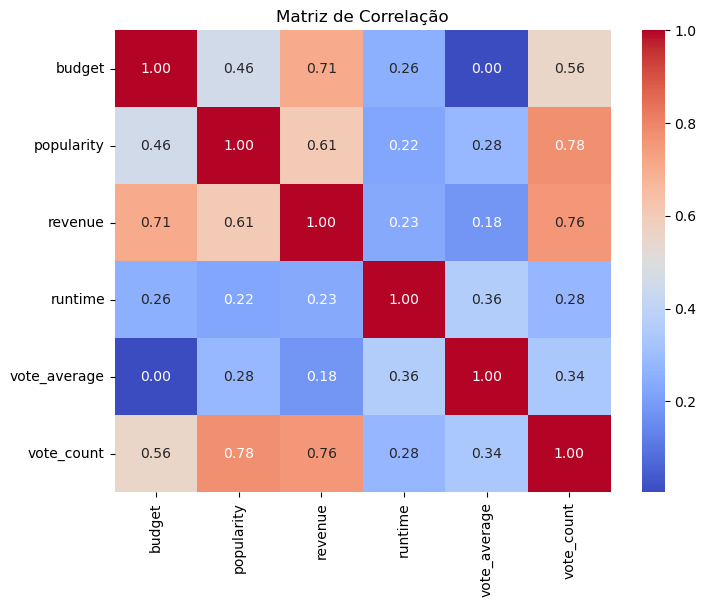

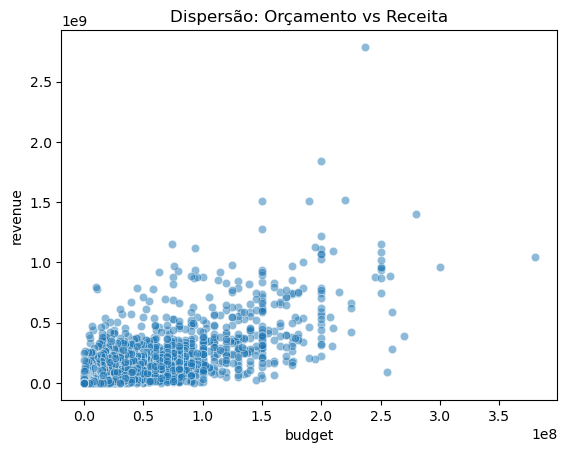

In [3]:
# Matriz de Correlação
corr_matrix = df[['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

# Gráfico de Dispersão
sns.scatterplot(data=df, x='budget', y='revenue', alpha=0.5)
plt.title('Dispersão: Orçamento vs Receita')
plt.show()

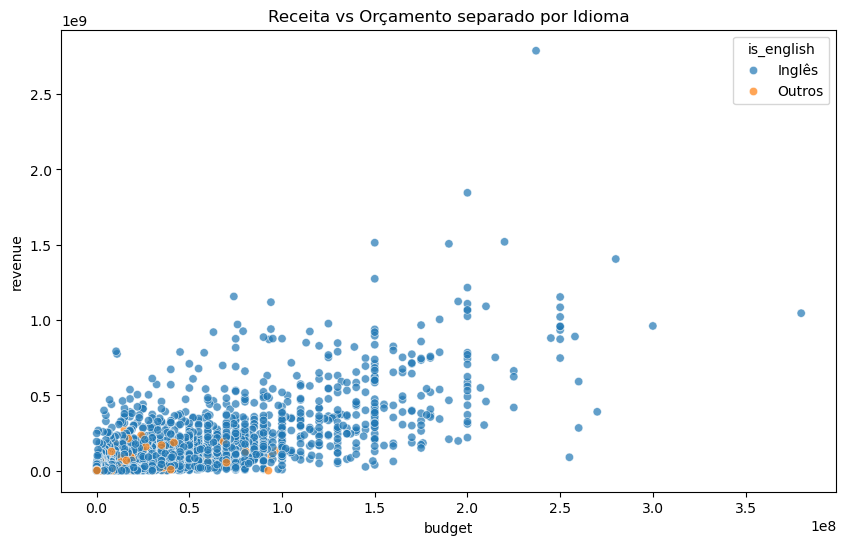

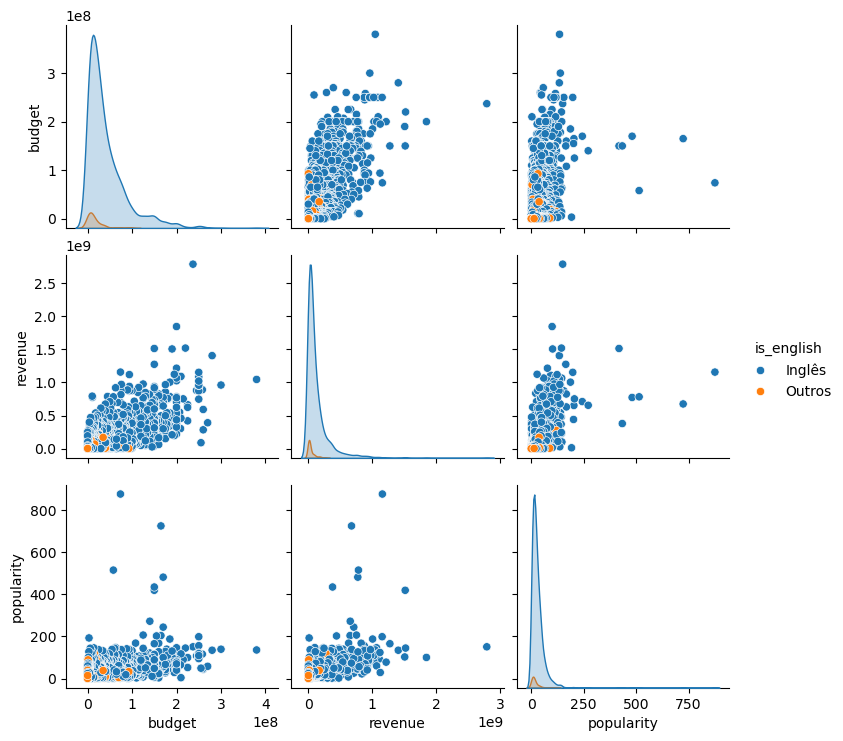

In [4]:
# Criando um separador de filmes em Inglês e Outros idiomas
df['is_english'] = df['original_language'].apply(lambda x: 'Inglês' if x == 'en' else 'Outros')

# Visualização Multivariada 1: Dispersão com Hue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='budget', y='revenue', hue='is_english', alpha=0.7)
plt.title('Receita vs Orçamento separado por Idioma')
plt.show()

# Visualização Multivariada 2: Pairplot de correlações com densidade
sns.pairplot(df[['budget', 'revenue', 'popularity', 'is_english']].dropna(), hue='is_english')
plt.show()